In [7]:
# as kernel we will be working with the lab as backend  

from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load the Wisconsin Breast Cancer dataset
data = load_breast_cancer()

# Create a DataFrame with the dataset
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # Add target (diagnosis) column

# Display ALL THE ROW FOR EXPLORATION 

df.head()

# Describe the first few columns
# df.iloc[:, :].describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# DATA VISUALISATION 

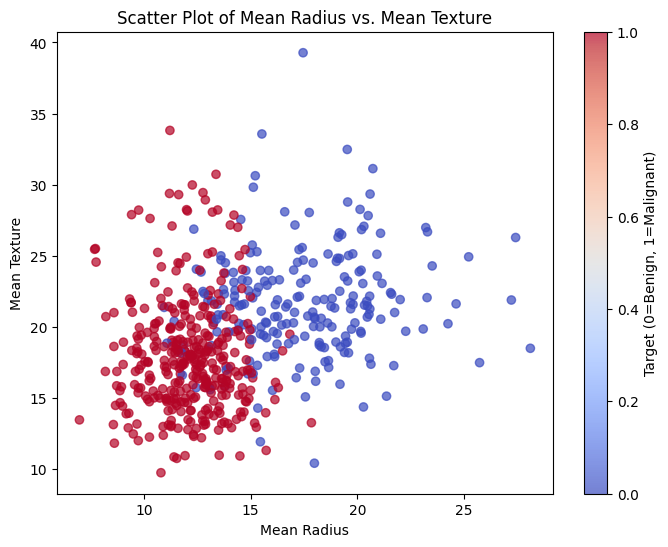

In [2]:
import matplotlib.pyplot as plt

# Scatter plot for two features
plt.figure(figsize=(8, 6))
plt.scatter(df['mean radius'], df['mean texture'], c=df['target'], cmap='coolwarm', alpha=0.7)
plt.colorbar(label='Target (0=Benign, 1=Malignant)')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.title('Scatter Plot of Mean Radius vs. Mean Texture')
plt.show()


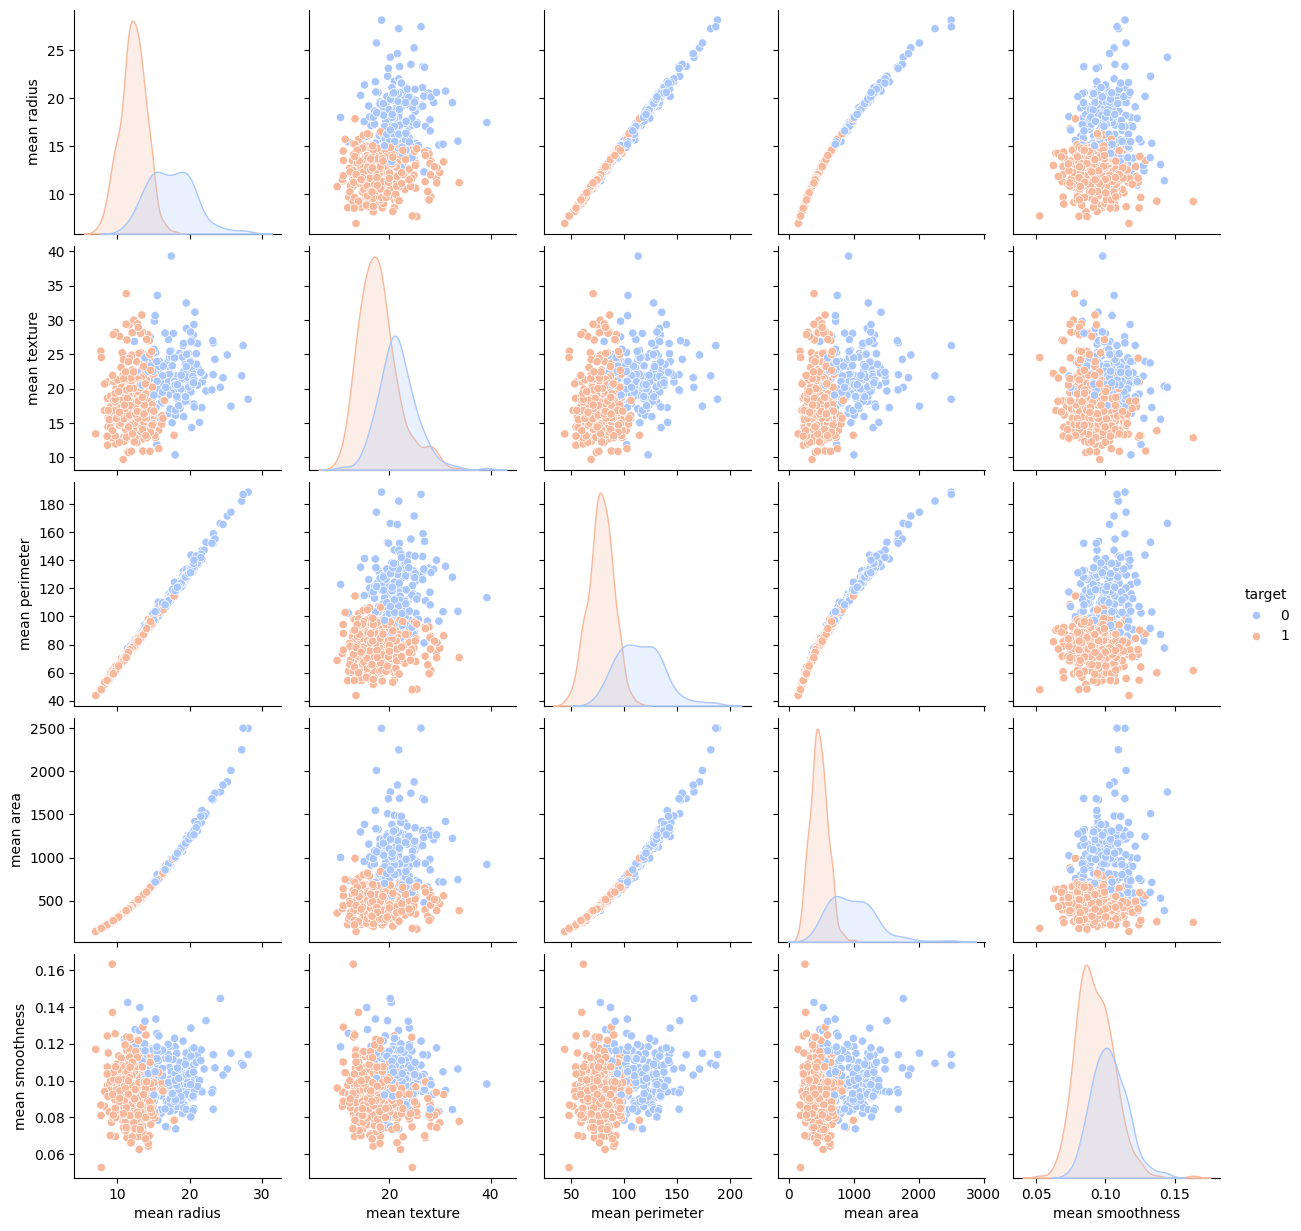

In [4]:
import seaborn as sns

# Select a subset of features
features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
pair_data = df[features + ['target']]

# Pair plot
sns.pairplot(pair_data, hue='target', diag_kind='kde', palette='coolwarm')
plt.show()


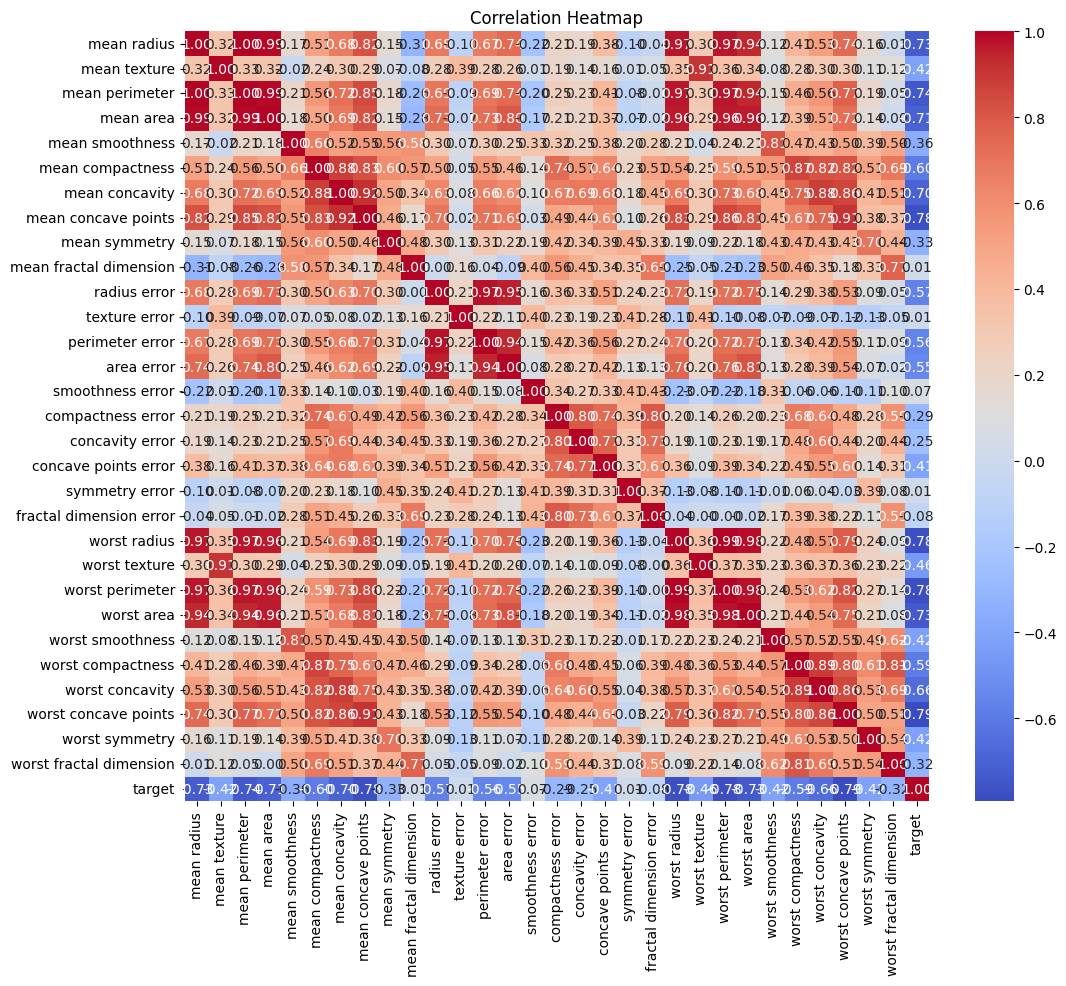

In [5]:
# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.show()


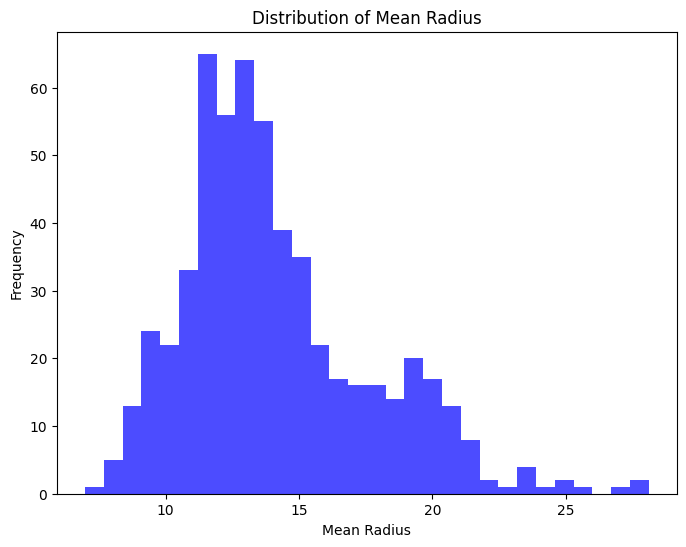

In [6]:
# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(df['mean radius'], bins=30, color='blue', alpha=0.7)
plt.xlabel('Mean Radius')
plt.ylabel('Frequency')
plt.title('Distribution of Mean Radius')
plt.show()


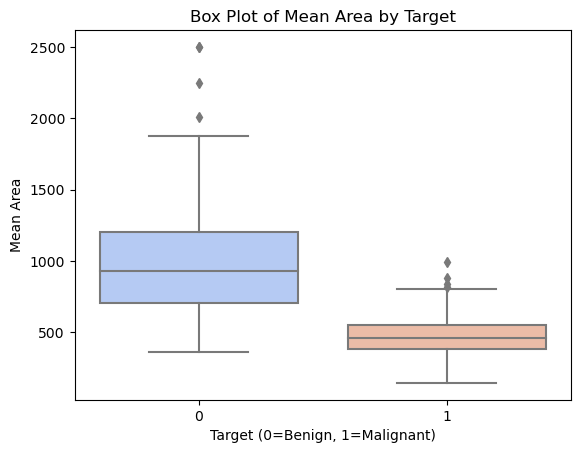

In [7]:
# Box plot
sns.boxplot(x='target', y='mean area', data=df, palette='coolwarm')
plt.xlabel('Target (0=Benign, 1=Malignant)')
plt.ylabel('Mean Area')
plt.title('Box Plot of Mean Area by Target')
plt.show()


# TRYING WITH CLASSICAL METHIDES FOR FEATUR SELECTION AND PERFARMANCE SA

In [ ]:
import pandas as pd
from sklearn.datasets          import load_breast_cancer
from sklearn.preprocessing     import StandardScaler, MinMaxScaler
from sklearn.model_selection   import train_test_split
from sklearn.feature_selection import RFECV
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier

# 1) Load data
data  = load_breast_cancer()
X_raw = pd.DataFrame(data.data, columns=data.feature_names)
y     = data.target

# 2) Define scalers & estimators
scalers = {
    "Standardization": StandardScaler(),
    "Normalization":   MinMaxScaler()
}
estimators = {
    "Logistic Regression": LogisticRegression(
        penalty='l1', solver='saga',
        max_iter=5000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 3) Run RFECV and collect results
results = []
for scale_name, scaler in scalers.items():
    X_scaled = scaler.fit_transform(X_raw)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    for est_name, est in estimators.items():
        rfecv = RFECV(estimator=est, step=1, cv=5, scoring='accuracy', n_jobs=-1)
        rfecv.fit(X_tr, y_tr)
        
        sel_feats = list(X_raw.columns[rfecv.support_])
        results.append({
            "Scaling":           scale_name,
            "Estimator":         est_name,
            "Optimal Features":  rfecv.n_features_,
            "Selected Features": sel_feats
        })

# 4) Build DataFrame and display
results_df = pd.DataFrame(results)

# If you’re in a notebook, just:
display(results_df)

# Otherwise, to print in the console:
print(results_df.to_string(index=False))


In [71]:
# classical_df  = classical_df.drop_duplicates(keep='first')

classical_df  = pd.read_csv('classical_results.csv')
classical_df 


,Scaling,RFE Estimator,Selected Features,Optimal n_features,Train Accuracy,Test Accuracy,Overfit Score
0,Standardization,Logistic Regression,"['mean concave points', 'radius error', 'compa...",7,0.975824,0.964912,0.010912
1,Standardization,Random Forest,"['mean radius', 'mean texture', 'mean perimete...",18,1.000000,0.964912,0.035088
2,Normalization,Logistic Regression,"['mean concave points', 'worst radius', 'worst...",4,0.971429,0.956140,0.015288
3,Normalization,Random Forest,"['mean radius', 'mean texture', 'mean perimete...",18,1.000000,0.964912,0.035088
4,Normalization,Random Forest,"['mean radius', 'mean texture', 'mean perimete...",18,1.000000,0.964912,0.035088
5,Normalization,Random Forest,"['mean concave points', 'worst perimeter', 'wo...",4,1.000000,0.956140,0.043860
6,Normalization,Random Forest,"['mean perimeter', 'mean concavity', 'mean con...",7,1.000000,0.956140,0.043860
7,Standardization,Random Forest,"['mean radius', 'mean texture', 'mean perimete...",18,1.000000,0.964912,0.035088
8,Standardization,Random Forest,"['mean concave points', 'worst perimeter', 'wo...",4,1.000000,0.956140,0.043860
9,Standardization,Random Forest,"['mean perimeter', 'mean concavity', 'mean con...",7,1.000000,0.956140,0.043860


In [74]:
import pandas as pd
from sklearn.datasets          import load_breast_cancer
from sklearn.preprocessing     import StandardScaler, MinMaxScaler
from sklearn.model_selection   import train_test_split
from sklearn.feature_selection import RFE
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import accuracy_score

# 1) Load the CSV, parsing the list column back into actual lists
csv_path = 'classical_results.csv'
df = pd.read_csv(csv_path, converters={'Selected Features': pd.eval})

# 2) Prepare raw data once
data  = load_breast_cancer()
X_raw = pd.DataFrame(data.data, columns=data.feature_names)
y     = data.target

# 3) Iterate only over rows missing the estimator
for idx, row in df[df['RFE Estimator'].isna()].iterrows():
    scale    = row['Scaling']
    n_feats  = int(row['Optimal n_features'])
    # choose the correct scaler
    scaler   = StandardScaler() if scale=='Standardization' else MinMaxScaler()
    X_scaled = scaler.fit_transform(X_raw)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    # run RFE for exactly n_feats features
    rfe = RFE(
        estimator=RandomForestClassifier(random_state=42),
        n_features_to_select=n_feats,
        step=1
    )
    rfe.fit(X_tr, y_tr)
    
    # gather the results
    sel_feats = X_raw.columns[rfe.support_].tolist()
    X_tr_rfe  = rfe.transform(X_tr)
    X_te_rfe  = rfe.transform(X_te)
    train_acc = accuracy_score(y_tr, rfe.estimator_.predict(X_tr_rfe))
    test_acc  = accuracy_score(y_te, rfe.estimator_.predict(X_te_rfe))
    overfit   = train_acc - test_acc
    
    # fill back into the DataFrame
    df.at[idx, 'RFE Estimator']     = f"Random Forest ({n_feats})"
    df.at[idx, 'Selected Features'] = sel_feats
    df.at[idx, 'Train Accuracy']    = train_acc
    df.at[idx, 'Test Accuracy']     = test_acc
    df.at[idx, 'Overfit Score']     = overfit

# 4) (Optional) sort and reset index
df = df.sort_values(
    by=['Scaling','RFE Estimator','Optimal n_features']
).reset_index(drop=True)

# 5) Save back to CSV (lists will be written as strings)
df.to_csv(csv_path, index=False)

print("Re‑calculated all fixed‑RFE rows and saved to", csv_path)


Re‑calculated all fixed‑RFE rows and saved to classical_results.csv


# QUNTUM SIMULATION


In [ ]:
# ---------------------------------------
# 1) Patch for missing _circuit_key (if needed)
# ---------------------------------------
import sys
try:
    from qiskit.primitives.utils import _circuit_key
except ImportError:
    def _circuit_key(circuit):
        return repr(circuit)
    import types
    utils = types.ModuleType("qiskit.primitives.utils")
    utils._circuit_key = _circuit_key
    sys.modules["qiskit.primitives.utils"] = utils

# ---------------------------------------
# 2) Load classical RFE results
# ---------------------------------------
import ast
import pandas as pd

df = pd.read_csv('classical_results.csv')

# Only rerun these two pipelines:
pipelines = [
    ('Normalization', 'Logistic Regression'),
    ('Standardization', 'Logistic Regression'),
]

# ---------------------------------------
# 3) Raw data & fixed train/test split
# ---------------------------------------
from sklearn.datasets        import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X_raw = pd.DataFrame(data.data, columns=data.feature_names)
y     = data.target

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

# ---------------------------------------
# 4) Quantum imports (statevector kernel + AerSampler)
# ---------------------------------------
import numpy as np
from sklearn.metrics import accuracy_score

from qiskit.circuit.library    import ZZFeatureMap, ZFeatureMap, PauliFeatureMap, RealAmplitudes
from qiskit_machine_learning.kernels      import FidelityStatevectorKernel  # statevector kernel :contentReference[oaicite:1]{index=1}
from qiskit_machine_learning.algorithms.classifiers import QSVC, VQC  # VQC now uses sampler= :contentReference[oaicite:2]{index=2}
from qiskit_machine_learning.optimizers          import COBYLA
from qiskit_aer                                 import AerSimulator               # Aer simulator 
from qiskit_aer.primitives                     import Sampler as AerSampler    # V2 sampler primitive 

backend         = AerSimulator()
sampler_primitive = AerSampler()  # for VQC

# ---------------------------------------
# 5) Training helpers
# ---------------------------------------
def train_qsvc(X_tr, X_te, y_tr, y_te, fmap):
    qk  = FidelityStatevectorKernel(feature_map=fmap)
    clf = QSVC(quantum_kernel=qk)
    clf.fit(X_tr, y_tr)
    return accuracy_score(y_te, clf.predict(X_te))

def train_vqc(X_tr, X_te, y_tr, y_te, fmap):
    ansatz = RealAmplitudes(num_qubits=X_tr.shape[1], reps=1)
    opt    = COBYLA(maxiter=100)
    # Pass AerSampler via sampler=, not quantum_instance
    vqc    = VQC(feature_map=fmap, ansatz=ansatz,
                 optimizer=opt, sampler=sampler_primitive)
    vqc.fit(X_tr, y_tr)
    return accuracy_score(y_te, vqc.predict(X_te))

# ---------------------------------------
# 6) Sweep settings
# ---------------------------------------
feature_map_builders = {
    'ZZFeatureMap':    lambda d, r, e: ZZFeatureMap(feature_dimension=d, reps=r, entanglement=e),
    'ZFeatureMap':     lambda d, r, e: ZFeatureMap(feature_dimension=d, reps=r),
    'PauliFeatureMap': lambda d, r, e: PauliFeatureMap(feature_dimension=d, reps=r, entanglement=e),
}
entanglements = ['full', 'linear', 'circular']
reps = 2

# ---------------------------------------
# 7) Run quantum sweep & collect results
# ---------------------------------------
quantum_results = []

for scale, estimator in pipelines:
    # pick the row and parse its features
    row   = df[(df['Scaling']==scale)&(df['RFE Estimator']==estimator)].iloc[0]
    feats = ast.literal_eval(row['Selected Features'])
    
    X_tr = X_train_full[feats].values
    X_te = X_test_full[feats].values
    
    print(f"\n=== {scale} + {estimator} ({len(feats)} features) ===")
    for fmap_name, builder in feature_map_builders.items():
        for ent in entanglements:
            fmap     = builder(d=X_tr.shape[1], r=reps, e=ent)
            qsvc_acc = train_qsvc(X_tr, X_te, y_train, y_test, fmap)
            vqc_acc  = train_vqc(X_tr, X_te, y_train, y_test, fmap)
            print(f"{fmap_name} | ent={ent:<8} | QSVC={qsvc_acc:.2%} | VQC={vqc_acc:.2%}")
            quantum_results.append({
                'Scaling':       scale,
                'Estimator':     estimator,
                'n_features':    len(feats),
                'Feature_Map':   fmap_name,
                'Entanglement':  ent,
                'Reps':          reps,
                'QSVC_Accuracy': qsvc_acc,
                'VQC_Accuracy':  vqc_acc
            })

# ---------------------------------------
# 8) Build DataFrame & save
# ---------------------------------------
quantum_results_df = pd.DataFrame(quantum_results)
print("\nQuantum Results Summary:")
print(quantum_results_df)

# Save for future reuse:
quantum_results_df.to_csv('quantum_results.csv', index=False)




=== Normalization + Logistic Regression (4 features) ===
ZZFeatureMap | ent=full     | QSVC=60.53% | VQC=47.37%
ZZFeatureMap | ent=linear   | QSVC=56.14% | VQC=47.37%
ZZFeatureMap | ent=circular | QSVC=58.77% | VQC=42.11%
ZFeatureMap | ent=full     | QSVC=88.60% | VQC=62.28%
ZFeatureMap | ent=linear   | QSVC=88.60% | VQC=62.28%
ZFeatureMap | ent=circular | QSVC=88.60% | VQC=61.40%
PauliFeatureMap | ent=full     | QSVC=60.53% | VQC=53.51%
PauliFeatureMap | ent=linear   | QSVC=56.14% | VQC=50.00%
PauliFeatureMap | ent=circular | QSVC=58.77% | VQC=44.74%

=== Standardization + Logistic Regression (7 features) ===
ZZFeatureMap | ent=full     | QSVC=62.28% | VQC=59.65%
ZZFeatureMap | ent=linear   | QSVC=82.46% | VQC=75.44%
ZZFeatureMap | ent=circular | QSVC=78.07% | VQC=65.79%
ZFeatureMap | ent=full     | QSVC=90.35% | VQC=62.28%
ZFeatureMap | ent=linear   | QSVC=90.35% | VQC=62.28%
ZFeatureMap | ent=circular | QSVC=90.35% | VQC=62.28%
PauliFeatureMap | ent=full     | QSVC=62.28% | VQC=48.

In [31]:
quantum_results_df

,Scaling,Estimator,n_features,Feature_Map,Entanglement,Reps,QSVC_Accuracy,VQC_Accuracy
0,Normalization,Logistic Regression,4,ZZFeatureMap,full,2,0.605263,0.473684
1,Normalization,Logistic Regression,4,ZZFeatureMap,linear,2,0.561404,0.473684
2,Normalization,Logistic Regression,4,ZZFeatureMap,circular,2,0.587719,0.421053
3,Normalization,Logistic Regression,4,ZFeatureMap,full,2,0.885965,0.622807
4,Normalization,Logistic Regression,4,ZFeatureMap,linear,2,0.885965,0.622807
5,Normalization,Logistic Regression,4,ZFeatureMap,circular,2,0.885965,0.614035
6,Normalization,Logistic Regression,4,PauliFeatureMap,full,2,0.605263,0.535088
7,Normalization,Logistic Regression,4,PauliFeatureMap,linear,2,0.561404,0.500000
8,Normalization,Logistic Regression,4,PauliFeatureMap,circular,2,0.587719,0.447368
9,Standardization,Logistic Regression,7,ZZFeatureMap,full,2,0.622807,0.596491


In [36]:
classical_df

,Scaling,RFE Estimator,Selected Features,Optimal n_features,Train Accuracy,Test Accuracy,Overfit Score
0,Standardization,Logistic Regression,"['mean concave points', 'radius error', 'compa...",7,0.975824,0.964912,0.010912
1,Standardization,Random Forest,"['mean radius', 'mean texture', 'mean perimete...",18,1.000000,0.964912,0.035088
2,Normalization,Logistic Regression,"['mean concave points', 'worst radius', 'worst...",4,0.971429,0.956140,0.015288
3,Normalization,Random Forest,"['mean radius', 'mean texture', 'mean perimete...",18,1.000000,0.964912,0.035088
4,Standardization,Random Forest (4),"['mean concave points', 'worst perimeter', 'wo...",4,1.000000,0.956140,0.043860
5,Standardization,Random Forest (7),"['mean perimeter', 'mean concavity', 'mean con...",7,1.000000,0.956140,0.043860
6,Normalization,Random Forest (4),"['mean concave points', 'worst perimeter', 'wo...",4,1.000000,0.956140,0.043860
7,Normalization,Random Forest (7),"['mean perimeter', 'mean concavity', 'mean con...",7,1.000000,0.956140,0.043860


In [21]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
import pandas as pd

from qiskit_machine_learning.algorithms.classifiers import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.circuit.library import ZZFeatureMap

# Step 1: Load the Dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Step 2: Separate Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Step 3: Standardize Features (important for SVM and QSVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 5: Apply RFE to Select Top Features
rf_model = RandomForestClassifier(random_state=42)  # Use Random Forest as the estimator
rfe = RFE(estimator=rf_model, n_features_to_select=4, step=1)  # Select top 4 features
rfe.fit(X_train, y_train)

# Get selected features
selected_features = X.columns[rfe.support_]
print("Selected Features:", selected_features)

# Transform dataset with selected features
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

# Step 6: Define Quantum Feature Map with Selected Features
feature_map = ZZFeatureMap(feature_dimension=X_train_rfe.shape[1], reps=2, entanglement='full')

# Step 7: Initialize Quantum Kernel and QSVC
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
qsvc = QSVC(quantum_kernel=quantum_kernel)

# Step 8: Train the QSVC
qsvc.fit(X_train_rfe, y_train)

# Step 9: Predict and Evaluate the Model
y_pred = qsvc.predict(X_test_rfe)
accuracy = accuracy_score(y_test, y_pred)
print(f"QSVC Accuracy with Selected Features: {accuracy:.2%}")


Selected Features: Index(['mean concave points', 'worst perimeter', 'worst area',
       'worst concave points'],
      dtype='object')
QSVC Accuracy with Selected Features: 66.67%


In [34]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
import pandas as pd

from qiskit_machine_learning.algorithms.classifiers import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.circuit.library import ZZFeatureMap

# Step 1: Load the Dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Step 2: Separate Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Step 3: Standardize Features (important for SVM and QSVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 5: Apply RFE to Select Top Features
rf_model = RandomForestClassifier(random_state=42)  # Use Random Forest as the estimator
rfe = RFE(estimator=rf_model, n_features_to_select=4, step=1)  # Select top 4 features
rfe.fit(X_train, y_train)

# Get selected features
selected_features = X.columns[rfe.support_]
print("Selected Features:", selected_features)

# Transform dataset with selected features
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

# Step 6: Define Quantum Feature Map with Selected Features
feature_map = ZZFeatureMap(feature_dimension=X_train_rfe.shape[1], reps=2, entanglement='full')

# Step 7: Initialize Quantum Kernel and QSVC
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
qsvc = QSVC(quantum_kernel=quantum_kernel)

# Step 8: Train the QSVC
qsvc.fit(X_train_rfe, y_train)

# Step 9: Predict and Evaluate the Model
y_pred = qsvc.predict(X_test_rfe)
accuracy = accuracy_score(y_test, y_pred)
print(f"QSVC Accuracy with Selected Features: {accuracy:.2%}")


Selected Features: Index(['mean concave points', 'worst perimeter', 'worst area',
       'worst concave points'],
      dtype='object')


KeyboardInterrupt: 

In [ ]:
kernel_matrix_train = quantum_kernel.evaluate(x_vec=X_train_rfe)
print("Kernel Matrix (Training Data):")
print(kernel_matrix_train)

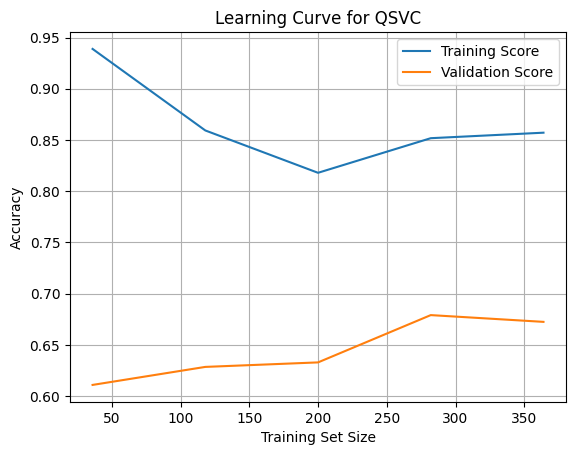

In [12]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(qsvc, X_train_rfe, y_train, cv=5)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Validation Score')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Learning Curve for QSVC")
plt.grid()
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10]}
grid_search = GridSearchCV(qsvc, param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_train_rfe, y_train)
print("Best Parameters:", grid_search.best_params_)
# SELECT THE PARAMETRES 

In [13]:
#  ruing the classical svm 
from sklearn.svm import SVC
classical_svc = SVC(kernel='rbf', C=1.0)
classical_svc.fit(X_train_rfe, y_train)
y_pred_classical = classical_svc.predict(X_test_rfe)
accuracy_classical = accuracy_score(y_test, y_pred_classical)
print(f"Classical SVM Accuracy: {accuracy_classical:.2%}")


Classical SVM Accuracy: 94.74%


# runing  in real QPU


In [1]:
# Import required libraries
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.circuit.library import ZZFeatureMap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.svm import SVC as SklearnSVC
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, Session 
from qiskit.primitives import BackendSamplerV2
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.algorithms import QSVC
import numpy as np
from qiskit_ibm_runtime import EstimatorV2 as Estimator



PREPROSESSING OF THE DATA 


In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.svm import SVC as SklearnSVC
from sklearn.utils import resample

# Load the dataset and preprocess
data = load_breast_cancer()
X, y = data.data, data.target

# Normalize features to [0, 1]
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split into training and testing sets (using stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature selection using Recursive Feature Elimination (RFE)
base_estimator = SklearnSVC(kernel='linear', C=1, random_state=42)
rfe = RFE(estimator=base_estimator, n_features_to_select=2)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

# Down-sample training data to 10 samples per class
n_samples_per_class = 10
X_train_rfe_down_list = []
y_train_down_list = []

for class_label in np.unique(y_train):
    X_class = X_train_rfe[y_train == class_label]
    y_class = y_train[y_train == class_label]
    # Downsample to 10 samples per class (if possible)
    X_class_down, y_class_down = resample(
        X_class, y_class,
        n_samples=min(n_samples_per_class, len(X_class)),
        random_state=42,
        replace=False
    )
    X_train_rfe_down_list.append(X_class_down)
    y_train_down_list.append(y_class_down)

# Combine the downsampled subsets
X_train_rfe = np.vstack(X_train_rfe_down_list)
y_train = np.hstack(y_train_down_list)

print("Downsampled training set class counts:", dict(zip(*np.unique(y_train, return_counts=True))))



Downsampled training set class counts: {0: 10, 1: 10}


SAVING THE PREPROSSERED DATA

In [3]:

# Save preprocessed data to CSV files
np.savetxt("X_train_rfe.csv", X_train_rfe, delimiter=",")
np.savetxt("y_train.csv", y_train, delimiter=",")
np.savetxt("X_test_rfe.csv", X_test_rfe, delimiter=",")
# (Optionally save y_test if needed)
np.savetxt("y_test.csv", y_test, delimiter=",")

print("Preprocessed data saved to CSV files.")


Preprocessed data saved to CSV files.


LOEAD THE PREPROSSED DATA 

In [4]:
import numpy as np

# Load the preprocessed data using NumPy
X_train_rfe = np.loadtxt("X_train_rfe.csv", delimiter=",")
y_train = np.loadtxt("y_train.csv", delimiter=",")
X_test_rfe = np.loadtxt("X_test_rfe.csv", delimiter=",")
y_test = np.loadtxt("y_test.csv", delimiter=",")

print("Preprocessed data loaded ")


Preprocessed data loaded 


In [39]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel='ibm_quantum', 

    token='f9a92275e11dce2964c8d517ccf82fcb8d77a2dfc75b66e49415932d7b522a46a05b6494508c7b5e49f31ae89e4e5d3714a2ed5012180a0f9188a8ca59fcadb2',#UM6P
    #'b94d0211e1137727c2569c26119e7cee6586aca6f05b3e4ed96db598db411d7ab22f0024035acb5f6cbc799f1ddc0c64a41fceaee11ff76d759cf85ef60cf857',#UM5 
    # 'c3fd5dc4f0ad7ddf8e0a521cafaef7bab378786d257a0807e6c92b99d0359310f5861957fd891523bb6067772fc08fb3302b5ea2ebca87f376e78cd714501f0c',
    #'d4b9def20ff5e370cb64cb18cb32c99fefac1e9a37ed1b2b15ccd4592d203305e7c0a8aa1635bfd8a11b306c9539cf8010459e0a76e76262dcfbe71073ec2799',
    # '700901a60b1d658f5a8bf779a5bd08d2e84fcef30ac1787c292731228bd3bd623f83cefed9eda7ed560316df90630b43ee168055be93ab333b717a43b616c37c', 
    #FATI '0abfc01909bbbc98cb67ae0a74512a68741b9d51c594897c6cf1847ffca1c56b112d20d77bd1848d5af13d86424099758e4e820098618bd47e4dad500209a0be',
    
    overwrite=True
)
service = QiskitRuntimeService(channel='ibm_quantum')


# List available backends and their status
print("Available Backends:")
for backend in service.backends():
    print(f"{backend.name} | Pending Jobs: {backend.status().pending_jobs}")

Available Backends:
ibm_brisbane | Pending Jobs: 912
ibm_kyiv | Pending Jobs: 3
ibm_sherbrooke | Pending Jobs: 7


In [40]:
backend = service.least_busy(operational=True)

In [41]:
from qiskit.circuit.library import zz_feature_map

# Define the feature map parameters
feature_dimension = X_train_rfe.shape[1]  # Number of features in your dataset
reps = 2  # Number of repetitions; adjust as needed

# Create the feature map circuit
feature_map = zz_feature_map(feature_dimension=feature_dimension, reps=reps)

# Display the circuit
print(feature_map.decompose())  # Optional: Decomposes the circuit for readability


   ┌─────────┐┌─────────────────┐                                              »
0: ┤ U2(0,π) ├┤ U(0,0,2.0*x[0]) ├──■────────────────────────────────────────■──»
   ├─────────┤├─────────────────┤┌─┴─┐┌──────────────────────────────────┐┌─┴─┐»
1: ┤ U2(0,π) ├┤ U(0,0,2.0*x[1]) ├┤ X ├┤ U(0,0,2.0*(x[0] - π)*(x[1] - π)) ├┤ X ├»
   └─────────┘└─────────────────┘└───┘└──────────────────────────────────┘└───┘»
«   ┌─────────┐┌─────────────────┐                                         »
«0: ┤ U2(0,π) ├┤ U(0,0,2.0*x[0]) ├──■──────────────────────────────────────»
«   ├─────────┤├─────────────────┤┌─┴─┐┌──────────────────────────────────┐»
«1: ┤ U2(0,π) ├┤ U(0,0,2.0*x[1]) ├┤ X ├┤ U(0,0,2.0*(x[0] - π)*(x[1] - π)) ├»
«   └─────────┘└─────────────────┘└───┘└──────────────────────────────────┘»
«        
«0: ──■──
«   ┌─┴─┐
«1: ┤ X ├
«   └───┘


In [7]:
print(f"Feature map operates on {feature_map.num_qubits} qubits.")

Feature map operates on 2 qubits.


In [42]:
import os
import time
import numpy as np
import pandas as pd
from qiskit.circuit.library import ZFeatureMap
from qiskit import transpile
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit.quantum_info import SparsePauliOp

def calculate_fidelity_kernel_checkpoint_individual(backend, feature_map, X, Y=None, 
                                                      csv_filename="kernel_matrix_checkpoint.csv", 
                                                      max_retries=3, delay_between_jobs=60):
    """
    Compute the quantum kernel matrix element-by-element and save each computed element
    to a CSV file (each line contains: row_index, col_index, value). This version batches a full row’s experiments in one job.
    If a CSV file exists, it loads the saved elements and resumes only for missing ones.
    
    Parameters:
      - backend: Quantum backend for running experiments.
      - feature_map: Parameterized quantum circuit for data encoding.
      - X: Data for which to compute kernel rows (e.g., training data).
      - Y: Data for kernel columns (if None, uses X for a square matrix).
      - csv_filename: File where computed elements are saved.
      - max_retries: Maximum number of retries if a job fails (e.g., due to session issues).
      - delay_between_jobs: Delay in seconds between job submissions.
      
    Returns:
      - kernel_matrix: A NumPy array of shape (n_samples, n_cols).
    """
    n_samples = len(X)
    n_cols = len(X) if Y is None else len(Y)
    kernel_matrix = np.zeros((n_samples, n_cols))
    
    # Load previously computed elements (in triple format) if the checkpoint CSV exists.
    computed = {}  # keys: (i, j), value: kernel value
    if os.path.exists(csv_filename):
        try:
            df_existing = pd.read_csv(csv_filename, header=None)
            for _, row in df_existing.iterrows():
                i_idx, j_idx, val = int(row[0]), int(row[1]), row[2]
                computed[(i_idx, j_idx)] = val
                kernel_matrix[i_idx, j_idx] = val
            print(f"Loaded {len(computed)} computed elements from '{csv_filename}'.")
        except Exception as e:
            print("Error reading checkpoint file; starting fresh.", e)
            computed = {}
    else:
        print("No checkpoint file found; starting fresh.")
    
    # Prepare circuits: bind each data sample to the feature map parameters.
    circuits_X = [feature_map.assign_parameters(dict(zip(feature_map.parameters, x))) for x in X]
    if Y is None:
        circuits_Y = circuits_X
    else:
        circuits_Y = [feature_map.assign_parameters(dict(zip(feature_map.parameters, y))) for y in Y]
    
    # Transpile circuits using an initial layout.
    initial_layout = list(range(feature_map.num_qubits))
    transpiled_circuits_X = transpile(circuits_X, backend=backend, initial_layout=initial_layout)
    transpiled_circuits_Y = transpile(circuits_Y, backend=backend, initial_layout=initial_layout)
    
    # Define the observable (a tensor product of Z operators).
    num_qubits = transpiled_circuits_X[0].num_qubits
    observable = SparsePauliOp.from_list([("Z" * num_qubits, 1.0)])
    
    overall_start_time = time.time()
    
    # Process the kernel matrix row by row.
    for i in range(n_samples):
        # For each row, first check if all elements in that row are computed.
        row_complete = all((i, j) in computed for j in range(n_cols))
        if row_complete:
            print(f"Row {i} already computed; skipping.")
            continue
        
        success = False
        retries = 0
        while not success and retries < max_retries:
            try:
                with Session(backend=backend) as session:
                    estimator = Estimator(mode=session)
                    # --- Batching: Build a list of experiments for the full row.
                    # For each column, create a pair of experiments:
                    # one for the row circuit and one for the corresponding column circuit.
                    # (Here we assume the kernel value is computed from the result of the row circuit measurement.)
                    experiments = []
                    for j in range(n_cols):
                        experiments.append((transpiled_circuits_X[i], observable, []))
                        # If you wish to combine the row and column circuit in a more complex way,
                        # you can append an experiment for the column circuit as well.
                        # For now, we are using just the row circuit to compute a value.
                    
                    # Submit all experiments for row i in one job.
                    job = estimator.run(experiments)
                    time.sleep(delay_between_jobs)
                    res = job.result()  # res is a list-like container of PubResult objects.
                    
                    # Map the results back to the row. Since we have one experiment per column,
                    # the ordering of res matches the columns.
                    for j in range(n_cols):
                        value = res[j].data.evs.item()
                        kernel_matrix[i, j] = value
                        computed[(i, j)] = value
                        # Save this element immediately to the CSV file as a triple.
                        with open(csv_filename, 'a') as f:
                            f.write(f"{i},{j},{value}\n")
                success = True
            except Exception as e:
                retries += 1
                print(f"Error on row {i} (attempt {retries}/{max_retries}): {e}")
                if retries < max_retries:
                    print(f"Retrying row {i} after a delay...")
                    time.sleep(120)
                else:
                    raise e
        row_elapsed = time.time() - overall_start_time
        print(f"Row {i} computed and processed.")
    
    overall_elapsed = time.time() - overall_start_time
    print(f"Total computation time: {overall_elapsed:.2f} seconds.")
    return kernel_matrix



In [43]:
# Example usage:
# Compute the training kernel matrix using the element-by-element checkpointing with row batching.
train_kernel_matrix = calculate_fidelity_kernel_checkpoint_individual(backend=backend, 
                                                                      feature_map=feature_map, 
                                                                      X=X_train_rfe)
print("Training kernel matrix computed and saved.")

# Similarly, compute the test kernel matrix (with X_test_rfe as rows, and X_train_rfe as columns).
test_kernel_matrix = calculate_fidelity_kernel_checkpoint_individual(backend=backend, 
                                                                     feature_map=feature_map, 
                                                                     X=X_test_rfe, 
                                                                     Y=X_train_rfe, 
                                                                     csv_filename="test_kernel_matrix_checkpoint.csv")
print("Test kernel matrix computed and saved.")


Loaded 400 computed elements from 'kernel_matrix_checkpoint.csv'.
Row 0 already computed; skipping.
Row 1 already computed; skipping.
Row 2 already computed; skipping.
Row 3 already computed; skipping.
Row 4 already computed; skipping.
Row 5 already computed; skipping.
Row 6 already computed; skipping.
Row 7 already computed; skipping.
Row 8 already computed; skipping.
Row 9 already computed; skipping.
Row 10 already computed; skipping.
Row 11 already computed; skipping.
Row 12 already computed; skipping.
Row 13 already computed; skipping.
Row 14 already computed; skipping.
Row 15 already computed; skipping.
Row 16 already computed; skipping.
Row 17 already computed; skipping.
Row 18 already computed; skipping.
Row 19 already computed; skipping.
Total computation time: 0.01 seconds.
Training kernel matrix computed and saved.
Loaded 140 computed elements from 'test_kernel_matrix_checkpoint.csv'.
Row 0 already computed; skipping.
Row 1 already computed; skipping.
Row 2 already computed; 

c:\Users\souha\anaconda3\envs\lab\Lib\site-packages\qiskit_ibm_runtime\qiskit_runtime_service.py:863: UserWarning: Your current pending jobs are estimated to consume 37.804607999999995 quantum seconds, but you only have 13 quantum seconds left in your monthly quota; therefore, it is likely this job will be canceled
  warnings.warn(warning_message)


Row 20 computed and processed.
Error on row 21 (attempt 1/3): 'Failed to run program: \'403 Client Error: Forbidden for url: https://api.quantum.ibm.com/runtime/jobs. {"errors":[{"message":"Job create exceeds open plan job usage limits","code":4317,"solution":"Please wait until the beginning of next month to submit more jobs when your quota will reset.","more_info":"https://docs.quantum-computing.ibm.com/errors"}]}\''
Retrying row 21 after a delay...
Error on row 21 (attempt 2/3): 'Failed to run program: \'403 Client Error: Forbidden for url: https://api.quantum.ibm.com/runtime/jobs. {"errors":[{"message":"Job create exceeds open plan job usage limits","code":4317,"solution":"Please wait until the beginning of next month to submit more jobs when your quota will reset.","more_info":"https://docs.quantum-computing.ibm.com/errors"}]}\''
Retrying row 21 after a delay...
Error on row 21 (attempt 3/3): 'Failed to run program: \'403 Client Error: Forbidden for url: https://api.quantum.ibm.com

IBMRuntimeError: 'Failed to run program: \'403 Client Error: Forbidden for url: https://api.quantum.ibm.com/runtime/jobs. {"errors":[{"message":"Job create exceeds open plan job usage limits","code":4317,"solution":"Please wait until the beginning of next month to submit more jobs when your quota will reset.","more_info":"https://docs.quantum-computing.ibm.com/errors"}]}\''

In [4]:
# Import QSVC from Qiskit Machine Learning and classical SVC from scikit-learn.
from qiskit_machine_learning.algorithms import QSVC
from sklearn.svm import SVC

# --- Train the Quantum SVM (QSVC) ---
# Note: You may see warnings indicating that the 'kernel' argument is not used;
# QSVC now expects a 'quantum_kernel' object. In this case, since you have a precomputed
# kernel, the classical SVC may be more appropriate.
# qsvc = QSVC(kernel="precomputed")
# qsvc.fit(train_kernel_matrix, y_train)
# qsvc_accuracy = qsvc.score(test_kernel_matrix, y_test)
# print(f"QSVC Accuracy: {qsvc_accuracy * 100:.2f}%")

# --- Train the Classical SVM with a Precomputed Kernel ---

n_test = test_kernel_matrix.shape[0]
if len(y_test) != n_test:
    print(f"Adjusting y_test from {len(y_test)} to {n_test} to match test kernel matrix rows.")
    y_test = y_test[:n_test]



svm = SVC(kernel="precomputed")
svm.fit(train_kernel_matrix, y_train)
svm_accuracy = svm.score(test_kernel_matrix, y_test)
print(f"Classical SVM Accuracy: {svm_accuracy * 100:.2f}%")

Adjusting y_test from 114 to 21 to match test kernel matrix rows.
Classical SVM Accuracy: 52.38%


Preprocessed data loaded.


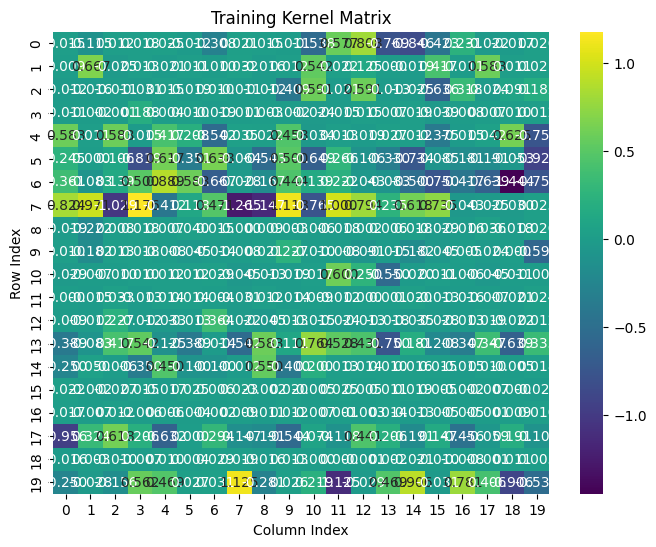

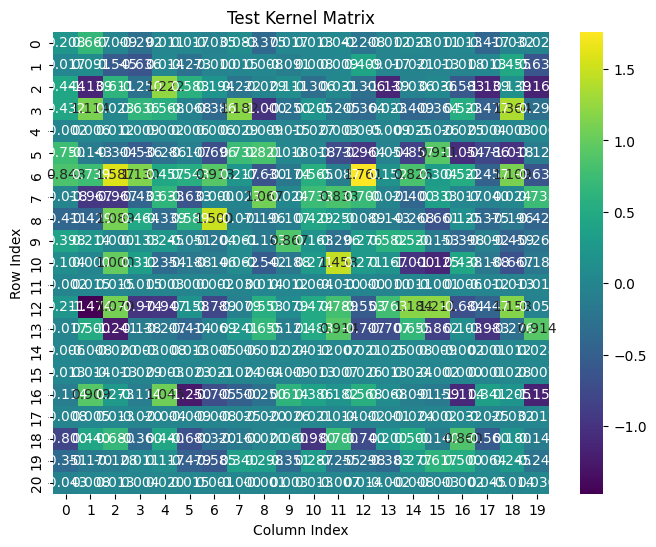

Adjusting y_test from 114 to 21 to match test kernel matrix rows.


C:\Users\souha\AppData\Local\Temp\ipykernel_11192\1498231981.py:70: QiskitMachineLearningWarning: "'kernel' argument is not supported and will be discarded, please use 'quantum_kernel' instead."
  qsvc = QSVC(kernel="precomputed")
C:\Users\souha\AppData\Local\Temp\ipykernel_11192\1498231981.py:70: QiskitMachineLearningWarning: 'No quantum kernel is provided, SamplerV1 based quantum kernel will be used.'
  qsvc = QSVC(kernel="precomputed")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Load Preprocessed Data ---

# Load the preprocessed data using NumPy.
X_train_rfe = np.loadtxt("X_train_rfe.csv", delimiter=",")
y_train = np.loadtxt("y_train.csv", delimiter=",")
X_test_rfe = np.loadtxt("X_test_rfe.csv", delimiter=",")
y_test = np.loadtxt("y_test.csv", delimiter=",")

print("Preprocessed data loaded.")

# --- Step 2: Load Precomputed Kernel Matrices ---

def load_kernel_matrix(csv_filename):
    """
    Load a kernel matrix from a CSV file stored in triple format.
    Each line in the CSV file should contain three values:
      row_index, col_index, kernel_value.
      
    Returns:
      - kernel_matrix: A NumPy array of shape (max_row+1, max_col+1)
    """
    df = pd.read_csv(csv_filename, header=None)
    max_row = int(df[0].max())
    max_col = int(df[1].max())
    kernel_matrix = np.zeros((max_row + 1, max_col + 1))
    for _, row in df.iterrows():
        i = int(row[0])
        j = int(row[1])
        kernel_matrix[i, j] = row[2]
    return kernel_matrix

# Load training and test kernel matrices from CSV files.
train_kernel_matrix = load_kernel_matrix("kernel_matrix_checkpoint.csv")
test_kernel_matrix  = load_kernel_matrix("test_kernel_matrix_checkpoint.csv")

# --- Step 3: Visualize Kernel Matrices (Optional) ---

def visualize_kernel_matrix(kernel_matrix, title="Kernel Matrix Heatmap"):
    plt.figure(figsize=(8, 6))
    sns.heatmap(kernel_matrix, annot=True, fmt=".3f", cmap="viridis")
    plt.title(title)
    plt.xlabel("Column Index")
    plt.ylabel("Row Index")
    plt.show()

visualize_kernel_matrix(train_kernel_matrix, title="Training Kernel Matrix")
visualize_kernel_matrix(test_kernel_matrix, title="Test Kernel Matrix")

# --- Step 4: Adjust Test Labels (if necessary) ---

n_test = test_kernel_matrix.shape[0]
if len(y_test) != n_test:
    print(f"Adjusting y_test from {len(y_test)} to {n_test} to match test kernel matrix rows.")
    y_test = y_test[:n_test]

# --- Step 5: Train and Evaluate QSVC and Classical SVM ---

# Import QSVC from Qiskit Machine Learning and classical SVC from scikit-learn.
from qiskit_machine_learning.algorithms import QSVC
from sklearn.svm import SVC

# --- Train the Quantum SVM (QSVC) ---
# Note: QSVC now expects a quantum_kernel object; however, if you wish to use your precomputed kernels directly,
# you might still see warnings when using kernel="precomputed". Here, we'll use the classical SVM as a baseline.
qsvc = QSVC(kernel="precomputed")
qsvc.fit(train_kernel_matrix, y_train)
qsvc_accuracy = qsvc.score(test_kernel_matrix, y_test)
print(f"QSVC Accuracy: {qsvc_accuracy * 100:.2f}%")

# --- Train the Classical SVM (SVC) with a Precomputed Kernel ---
svc = SVC(kernel="precomputed")
svc.fit(train_kernel_matrix, y_train)
svc_accuracy = svc.score(test_kernel_matrix, y_test)
print(f"Classical SVM Accuracy: {svc_accuracy * 100:.2f}%")


In [ ]:
import numpy as np
from sklearn.svm import SVC

# Suppose you already loaded your full kernel matrices:
# train_kernel_matrix (shape: n_train x n_train)
# test_kernel_matrix (shape: n_test x n_train)
# And you have y_train and y_test arrays.

# For example, let's create a smaller training set:
n_small_train = 5   # Use the first 5 training samples
n_small_test = 3    # Use the first 3 test samples

# Subset the training kernel matrix (only the first n_small_train rows and columns)
small_train_kernel_matrix = train_kernel_matrix[:n_small_train, :n_small_train]

# Subset the test kernel matrix (only the first n_small_test rows and first n_small_train columns)
small_test_kernel_matrix = test_kernel_matrix[:n_small_test, :n_small_train]

# Also subset your labels accordingly
small_y_train = y_train[:n_small_train]
small_y_test = y_test[:n_small_test]

# Train and evaluate a classical SVM with the smaller precomputed kernel matrices.
svc_small = SVC(kernel="precomputed")
svc_small.fit(small_train_kernel_matrix, small_y_train)
small_train_accuracy = svc_small.score(small_train_kernel_matrix, small_y_train)
small_test_accuracy = svc_small.score(small_test_kernel_matrix, small_y_test)

print(f"Small SVM Training Accuracy: {small_train_accuracy * 100:.2f}%")
print(f"Small SVM Test Accuracy: {small_test_accuracy * 100:.2f}%")


In [18]:
# --------------------------------------------------
# Define a custom quantum kernel that returns your precomputed kernel.
# In a full implementation, the evaluate() method should match the input vectors
# to rows/columns of the precomputed matrix. Here we assume the order is fixed.





from qiskit_machine_learning.kernels import FidelityQuantumKernel

class PrecomputedQuantumKernel(FidelityQuantumKernel):
    def __init__(self, kernel_matrix):
        # We do not need to call FidelityQuantumKernel's full constructor
        # since we are overriding evaluate() completely.
        self.kernel_matrix = kernel_matrix

    def evaluate(self, x_vec, y_vec=None):
        """
        For demonstration purposes, we assume that the ordering of the input data 
        matches exactly the ordering of samples in self.kernel_matrix.
        In practice, you would extract the submatrix corresponding to x_vec (and y_vec).
        """
        return self.kernel_matrix



# Assume that train_kernel_matrix is your precomputed training kernel matrix,
# and X_train_rfe, y_train, X_test_rfe, and y_test are your training and test data/labels.
precomputed_qkernel = PrecomputedQuantumKernel(train_kernel_matrix)

from qiskit_machine_learning.algorithms import QSVC

qsvc = QSVC(quantum_kernel=precomputed_qkernel)
qsvc.fit(X_train_rfe, y_train)
qsvc_accuracy = qsvc.score(test_kernel_matrix, y_test)
print(f"QSVC Accuracy: {qsvc_accuracy * 100:.2f}%")


# --------------------------------------------------
# Train and test a classical SVM using the precomputed kernel matrices.
from sklearn.svm import SVC

svc = SVC(kernel="precomputed")
svc.fit(train_kernel_matrix, y_train)
svc_accuracy = svc.score(test_kernel_matrix, y_test)
print(f"Classical SVM Accuracy: {svc_accuracy * 100:.2f}%")


ValueError: Found input variables with inconsistent numbers of samples: [21, 20]

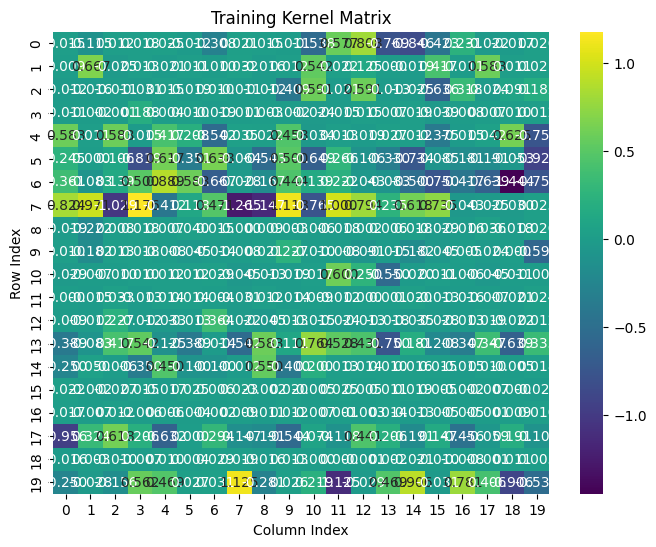

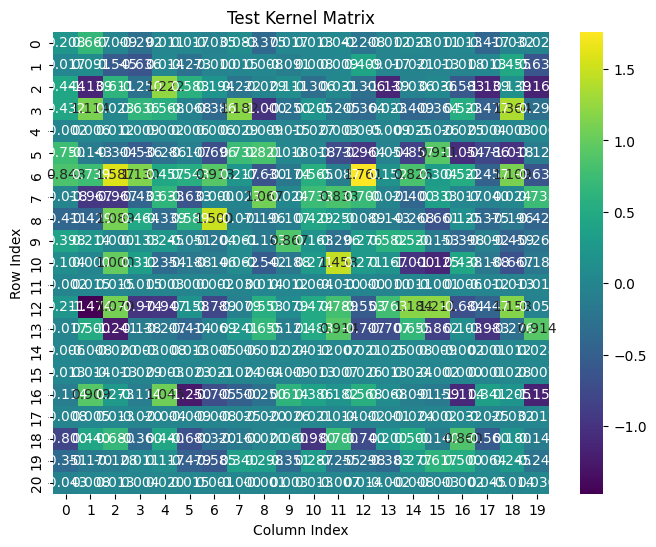

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_kernel_matrix(csv_filename):
    """
    Load a kernel matrix from a CSV file stored in triple format.
    Each line in the CSV file should contain three values:
      row_index, col_index, kernel_value.
      
    Returns:
      - kernel_matrix: A NumPy array of shape (max_row+1, max_col+1) reconstructed from the triples.
    """
    # Read the CSV file (no header, triple format)
    df = pd.read_csv(csv_filename, header=None)
    
    # Convert maximum row and column indices to integers
    max_row = int(df[0].max())
    max_col = int(df[1].max())
    
    # Create a full kernel matrix with the correct dimensions (indices are zero-based)
    kernel_matrix = np.zeros((max_row + 1, max_col + 1))
    
    # Fill in the kernel matrix using each triple (i, j, value)
    for _, row in df.iterrows():
        i = int(row[0])
        j = int(row[1])
        value = row[2]
        kernel_matrix[i, j] = value
    
    return kernel_matrix

def visualize_kernel_matrix(kernel_matrix, title="Kernel Matrix Heatmap"):
    """
    Visualize a kernel matrix using a heat map.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(kernel_matrix, annot=True, fmt=".3f", cmap="viridis")
    plt.title(title)
    plt.xlabel("Column Index")
    plt.ylabel("Row Index")
    plt.show()

# Example usage:
# Load and visualize the training kernel matrix.
train_kernel_matrix = load_kernel_matrix("kernel_matrix_checkpoint.csv")
visualize_kernel_matrix(train_kernel_matrix, title="Training Kernel Matrix")

# # Load and visualize the test kernel matrix.
test_kernel_matrix = load_kernel_matrix("test_kernel_matrix_checkpoint.csv")
visualize_kernel_matrix(test_kernel_matrix, title="Test Kernel Matrix")


In [ ]:
# Print the kernel matrices to the console.
print("Training Kernel Matrix:")
print(train_kernel_matrix)
print("\nTesting Kernel Matrix:")
print(test_kernel_matrix)

In [12]:
import qiskit
import qiskit_ibm_runtime
import qiskit_machine_learning

print("Qiskit version:", qiskit.__version__)
print("Qiskit IBM Runtime version:", qiskit_ibm_runtime.__version__)
print("Qiskit Machine Learning version:", qiskit_machine_learning.__version__)


Qiskit version: 1.3.2
Qiskit IBM Runtime version: 0.34.0
Qiskit Machine Learning version: 0.8.2


In [ ]:
%pip install --upgrade qiskit
%pip install --upgrade qiskit-ibm-runtime
%pip install --upgrade qiskit-machine-learning
